In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/islamabad_backfill_features.csv"

df = pd.read_csv(DATA_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

Matplotlib is building the font cache; this may take a moment.


,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,pm10,...,month,day_of_year,is_weekend,is_rush_hour,season,wind_u,wind_v,is_stagnant,temperature_humidity,aqi_change
0,2026-05-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.9,...,5,149,0,0,1,NaN,NaN,0,NaN,0.0
1,2026-05-29 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,...,5,149,0,0,1,NaN,NaN,0,NaN,0.0
2,2026-05-29 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.4,...,5,149,0,0,1,NaN,NaN,0,NaN,1.0
3,2026-05-29 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.4,...,5,149,0,0,1,NaN,NaN,0,NaN,0.0
4,2026-05-29 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.9,...,5,149,0,0,1,NaN,NaN,0,NaN,1.0


In [2]:
print("Shape:", df.shape)
print("\nDate range:")
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

print("\nColumns:")
print(df.columns.tolist())

Shape: (2160, 28)

Date range:
Start: 2026-05-29 00:00:00
End: 2026-08-26 23:00:00

Columns:
['timestamp', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'us_aqi', 'hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_rush_hour', 'season', 'wind_u', 'wind_v', 'is_stagnant', 'temperature_humidity', 'aqi_change']


In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

temperature_2m          485
relative_humidity_2m    485
dew_point_2m            485
surface_pressure        485
precipitation           485
wind_speed_10m          485
wind_direction_10m      485
wind_gusts_10m          485
wind_u                  485
wind_v                  485
temperature_humidity    485
dtype: int64


In [4]:
df.describe()

,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,pm10,...,month,day_of_year,is_weekend,is_rush_hour,season,wind_u,wind_v,is_stagnant,temperature_humidity,aqi_change
count,2160,1675.000000,1675.000000,1675.000000,1675.000000,1675.000000,1675.000000,1675.000000,1675.000000,2160.000000,...,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,1675.000000,1.675000e+03,2160.000000,1675.000000,2160.000000
mean,2026-07-12 23:29:59.999999744,29.161254,70.085373,22.473851,943.806090,0.197851,6.339940,130.589851,17.449194,52.879120,...,6.888889,193.500000,0.288889,0.250000,1.966667,3.480987,-2.418064e-01,0.052778,1985.286866,0.018519
min,2026-05-29 00:00:00,21.000000,25.000000,12.200000,937.500000,0.000000,0.200000,3.000000,2.200000,5.200000,...,5.000000,149.000000,0.000000,0.000000,1.000000,-11.497567,-1.229545e+01,0.000000,882.500000,-43.000000
25%,2026-06-20 11:45:00,26.300000,57.000000,21.500000,942.400000,0.000000,3.800000,68.000000,11.900000,33.400000,...,6.000000,171.000000,0.000000,0.000000,2.000000,0.503875,-2.845143e+00,0.000000,1782.800000,-1.000000
50%,2026-07-12 23:30:00,28.600000,72.000000,23.100000,943.900000,0.000000,6.100000,105.000000,16.900000,47.400000,...,7.000000,193.500000,0.000000,0.000000,2.000000,3.650058,5.939537e-16,0.000000,2062.500000,0.000000
75%,2026-08-04 11:15:00,31.700000,86.000000,24.100000,945.300000,0.100000,8.500000,163.500000,22.300000,65.400000,...,8.000000,216.000000,1.000000,0.250000,2.000000,7.055329,2.386110e+00,0.000000,2261.300000,1.000000
max,2026-08-26 23:00:00,40.000000,100.000000,26.700000,948.700000,8.500000,19.400000,360.000000,57.200000,338.100000,...,8.000000,238.000000,1.000000,1.000000,2.000000,18.897121,1.458091e+01,1.000000,2597.000000,41.000000
std,NaN,3.624824,18.069142,2.436914,2.102541,0.709044,3.262073,88.914741,7.334297,29.947826,...,0.862296,25.985174,0.453351,0.433113,0.179547,4.916958,3.807950e+00,0.223641,346.988324,9.374392


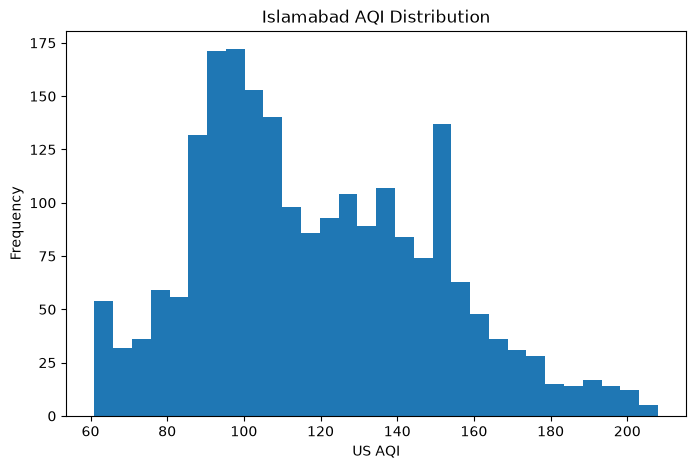

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["us_aqi"].dropna(),
    bins=30
)

plt.title("Islamabad AQI Distribution")
plt.xlabel("US AQI")
plt.ylabel("Frequency")

plt.show()

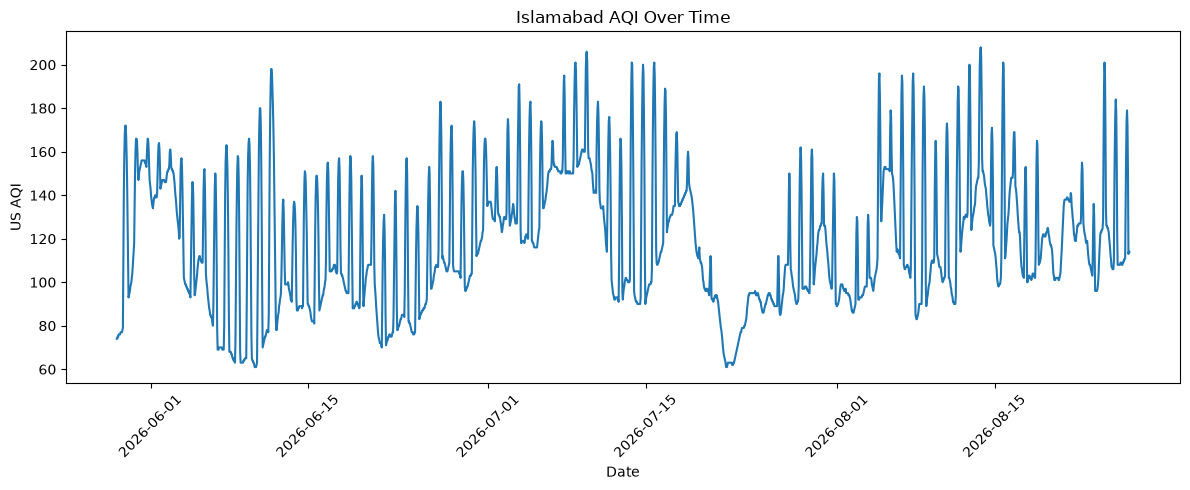

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["timestamp"],
    df["us_aqi"]
)

plt.title("Islamabad AQI Over Time")
plt.xlabel("Date")
plt.ylabel("US AQI")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

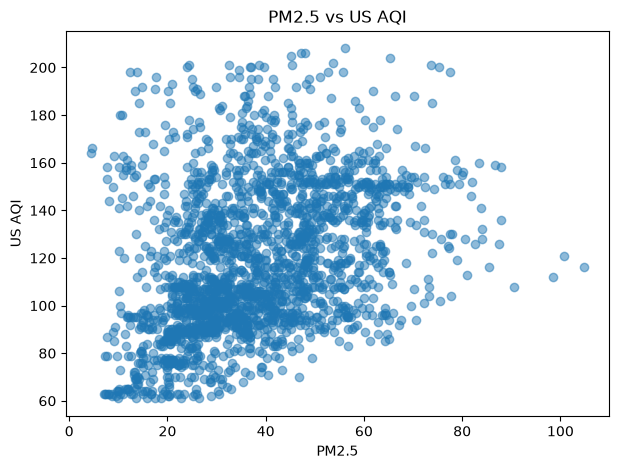

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["pm2_5"],
    df["us_aqi"],
    alpha=0.5
)

plt.title("PM2.5 vs US AQI")
plt.xlabel("PM2.5")
plt.ylabel("US AQI")

plt.show()

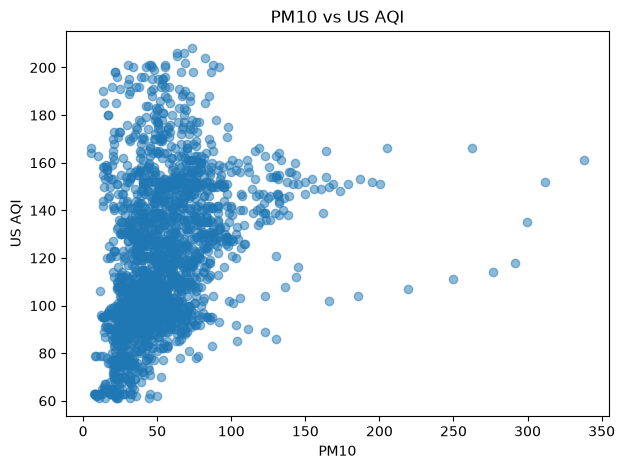

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["pm10"],
    df["us_aqi"],
    alpha=0.5
)

plt.title("PM10 vs US AQI")
plt.xlabel("PM10")
plt.ylabel("US AQI")

plt.show()

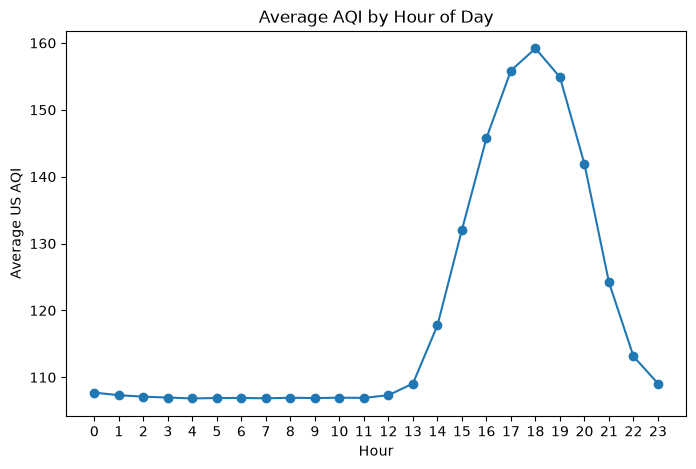

In [9]:
hourly_aqi = (
    df.groupby("hour")["us_aqi"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    hourly_aqi.index,
    hourly_aqi.values,
    marker="o"
)

plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average US AQI")

plt.xticks(range(0, 24))

plt.show()

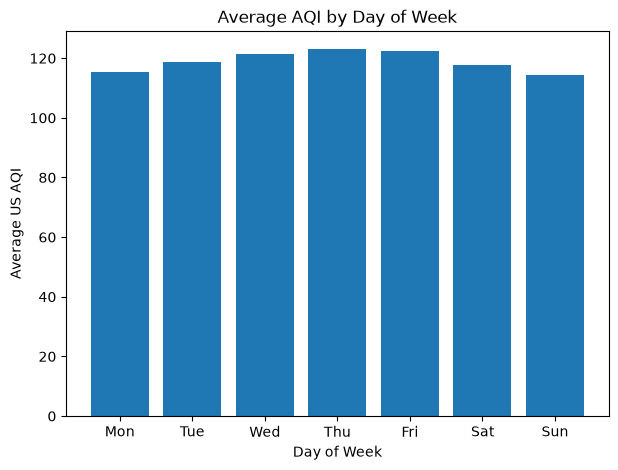

In [10]:
daily_aqi = (
    df.groupby("day_of_week")["us_aqi"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    daily_aqi.index,
    daily_aqi.values
)

plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average US AQI")

plt.xticks(
    range(7),
    [
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun",
    ]
)

plt.show()

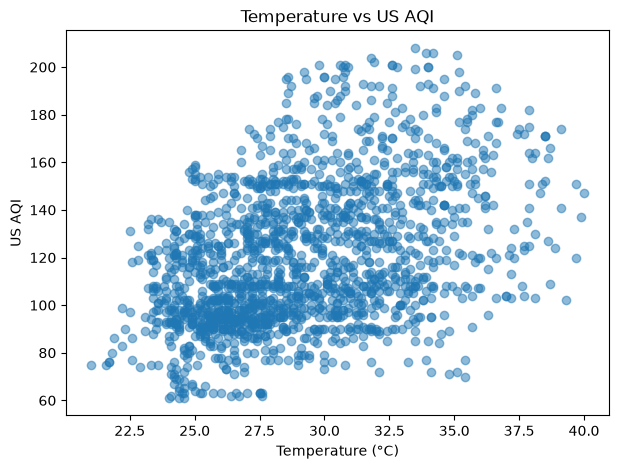

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["temperature_2m"],
    df["us_aqi"],
    alpha=0.5
)

plt.title("Temperature vs US AQI")
plt.xlabel("Temperature (°C)")
plt.ylabel("US AQI")

plt.show()

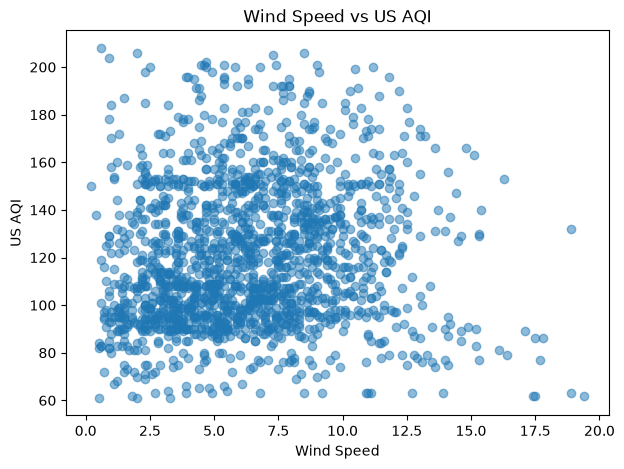

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["wind_speed_10m"],
    df["us_aqi"],
    alpha=0.5
)

plt.title("Wind Speed vs US AQI")
plt.xlabel("Wind Speed")
plt.ylabel("US AQI")

plt.show()

In [13]:
numeric_df = df.select_dtypes(
    include=["number"]
)

aqi_correlations = (
    numeric_df.corr()["us_aqi"]
    .sort_values(ascending=False)
)

print(aqi_correlations)

us_aqi                  1.000000
temperature_2m          0.422203
pm10                    0.359512
pm2_5                   0.356872
hour                    0.354469
sulphur_dioxide         0.279073
ozone                   0.276246
is_rush_hour            0.242579
carbon_monoxide         0.156217
aqi_change              0.151798
month                   0.132368
wind_gusts_10m          0.114585
wind_direction_10m      0.112822
wind_speed_10m          0.095444
dew_point_2m            0.081569
day_of_year             0.071479
day_of_week            -0.010543
nitrogen_dioxide       -0.034968
is_weekend             -0.061092
season                 -0.062964
wind_u                 -0.067632
is_stagnant            -0.082190
precipitation          -0.089200
wind_v                 -0.125693
temperature_humidity   -0.128109
relative_humidity_2m   -0.273376
surface_pressure       -0.366338
Name: us_aqi, dtype: float64
